In [70]:
from astropy.io import fits
from astropy.table import Table
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

In [71]:
hudl  = fits.open(r'data\nihao_uhd_simulation_g8.26e11_xyz_positions_and_oxygen_ao.fits')
print(hudl)
data = Table(hudl[1].data)
print(data.columns)

[<astropy.io.fits.hdu.image.PrimaryHDU object at 0x000001F322C42AD0>, <astropy.io.fits.hdu.table.BinTableHDU object at 0x000001F317456030>]
<TableColumns names=('x','y','z','A_O')>


In [72]:
data.add_column(np.sqrt(data['x']**2+data['y']**2),name = 'R_Gal')

In [73]:
def lin(x,m,c):
    return m*x+c

In [74]:
params, pcov = curve_fit(lin,data['R_Gal'],data['A_O'],p0=[-0.5/15,9.1])
data.add_column(lin(data['R_Gal'],*params),name = 'model')
data.add_column(data['A_O']-data['model'], name = 'residual')

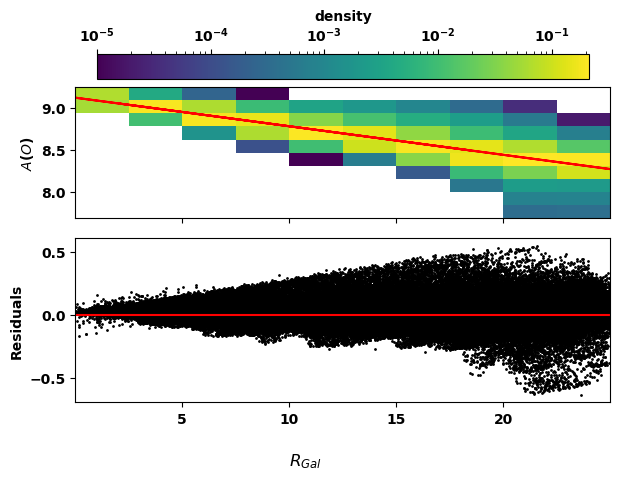

In [75]:
fig, axs = plt.subplots(2,sharex=True)
h, x_edge, y_edge, im = axs[0].hist2d(data['R_Gal'],data['A_O'],density = True,norm = 'log')
cbar = plt.colorbar(im,ax=axs[0],location = 'top',label='density')
axs[0].plot(data['R_Gal'],data['model'],c='r')
axs[0].set_ylabel('$A(O)$')
axs[1].scatter(data['R_Gal'],data['residual'],s=1,c='k')
axs[1].axhline(y=0,c='r')
axs[1].set_ylabel('Residuals')
fig.supxlabel('$R_{Gal}$')
fig.tight_layout()
fig.savefig(r'figures\A_vs_Grad.png')

In [76]:
print(f'the slope is m={params[0]:.5f}+-{np.sqrt(pcov[0,0]):.02}')
print(f'the intercept is c={params[1]:.4f}+-{np.sqrt(pcov[1,1]):.02}')

the slope is m=-0.03420+-1.5e-05
the intercept is c=9.1278+-0.00023


![](figures\A_vs_Grad.png)

using ```scipy.optimize.curvefit``` the slope and intercept of the linear model in the above plot are $m=-0.03420\pm1.5\times10^{-10},\;c=9.1278\pm0.00023$. these parameters were computed using a Levenberg-Marquardt algorithm for least squares fitting with no bounds and innitial conditions of $m_0=-\frac{1}{30},\;c_0=9.1$ which were estimated from reading the plot.

(array([[    0.,     0.,   873.,  1339.,  3280.,  3310.,  1701.,  1011.,
             0.,     0.],
        [    0.,  1742.,  2791.,  4965.,  6270.,  9550.,  8054.,  4503.,
          1863.,     0.],
        [ 2976.,  4177.,  1656.,  4949.,  8811.,  7248.,  4855.,  1261.,
          2649.,   845.],
        [ 3746.,  2838.,  2834.,  6940., 10478.,  8979., 13771.,  5579.,
          5733.,  5244.],
        [ 8018.,  6036.,  4470., 13154., 18439., 20127.,  8099.,  6621.,
          5234.,  5750.],
        [ 5420.,  5606., 10147., 10003., 18513., 17540.,  8474.,  5348.,
          5843.,  3931.],
        [ 3607.,  4276.,  2806.,  6757.,  8183.,  8265.,  5671.,  7471.,
          7438.,  5441.],
        [ 1302.,  6043.,  7585.,  4321.,  3995.,  6229.,  8219.,  6500.,
          7279.,  1295.],
        [    0.,  2549.,  4431.,  6803.,  4528.,  6550.,  5104.,  6176.,
          3522.,     0.],
        [    0.,     0.,   597.,  1180.,  3402.,  5401.,  3909.,  1091.,
             0.,     0.]]),
 array([

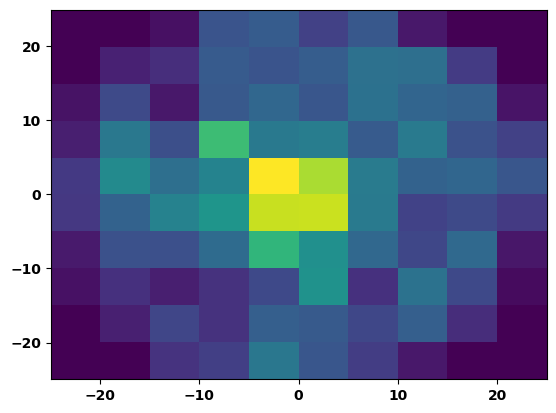

In [77]:
plt.hist2d(data['x'],data['y'])

In [93]:
percentile_options = [5**i*2**j for i in range(3) for j in range(3)]
num_stars = len(data)
pct = np.sqrt(500/num_stars)
pct = min(percentile_options, key=lambda x: abs(x-100*pct))
num_bins = int(100/pct)
x_bin_edges = [np.percentile(data['x'],pct*i) for i in range(num_bins)]
x_bin_edges.append(data['x'][-1])
y_bin_edges = [np.percentile(data['y'],pct*i) for i in range(num_bins)]
y_bin_edges.append(data['y'][-1])
x_bin_centers = [(x_bin_edges[i]+x_bin_edges[i+1])/2 for i in range(num_bins)]
y_bin_centers = [(y_bin_edges[i]+y_bin_edges[i+1])/2 for i in range(num_bins)]

In [79]:
data.add_column(np.ones_like(data['x']),name = 'x_bin')
data.add_column(np.ones_like(data['y']),name = 'y_bin')

In [80]:
for i,row in enumerate(data):
    for j in range(num_bins):
        if row['x']<=x_bin_edges[j+1] and row['x']>x_bin_edges[j]:
            row['x_bin'] = j
        if row['y']<=y_bin_edges[j+1] and row['y']>y_bin_edges[j]:
            row['y_bin'] = j

In [82]:
data['x_bin'][np.argmin(data['x'])] = 0.0
data['y_bin'][np.argmin(data['y'])] = 0.0

In [95]:
grouped_data = data.group_by(['x_bin','y_bin'])
binned_data = grouped_data.groups.aggregate(np.median)

In [102]:
binned_data['x_bin'] = binned_data['x_bin'].astype(int)
binned_data['y_bin'] = binned_data['y_bin'].astype(int)
binned_data['x'] = [x_bin_centers[i] for i in binned_data['x_bin']]
binned_data['y'] = [y_bin_centers[i] for i in binned_data['y_bin']]

In [105]:
grid = np.full((num_bins,num_bins),np.nan)
AO_sim_grid = grid.copy()
AO_sim_grid[binned_data['y_bin'],binned_data['x_bin']] = binned_data['A_O']
AO_mod_grid = grid.copy()
AO_res_grid = grid.copy()
AO_mod_grid[binned_data['y_bin'],binned_data['x_bin']] = binned_data['model']
AO_res_grid[binned_data['y_bin'],binned_data['x_bin']] = binned_data['residual']

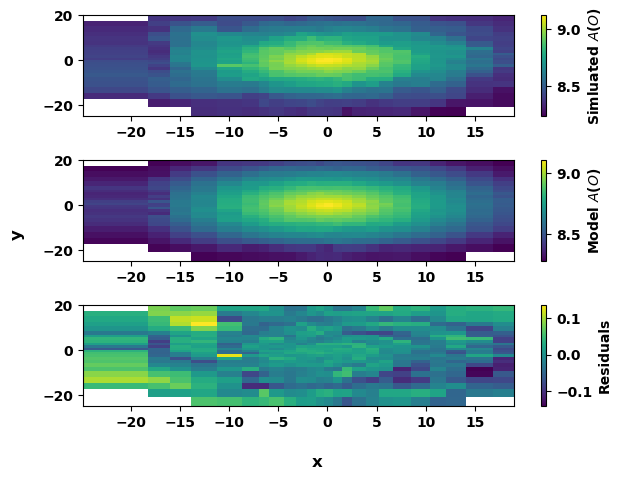

In [113]:
fig, axs = plt.subplots(3)
sim_img = axs[0].pcolormesh(x_bin_edges,y_bin_edges,AO_sim_grid)
plt.colorbar(sim_img,ax=axs[0],label=r'Simluated $A(O)$')
mod_img = axs[1].pcolormesh(x_bin_edges,y_bin_edges,AO_mod_grid)
plt.colorbar(mod_img,ax=axs[1],label=r'Model $A(O)$')
res_img = axs[2].pcolormesh(x_bin_edges,y_bin_edges,AO_res_grid)
plt.colorbar(res_img,ax=axs[2],label=r'Residuals')
fig.supxlabel('x')
fig.supylabel('y')
fig.tight_layout()
fig.savefig('figures/binned_AO')